# Model Selection and Evaluation Workshop
### Hands-on Notebook

**Learning Objectives**
1. Compare **regression and classification outcomes**
2. Integrate **Scikit-learn metrics** for final assessment

---
A delivery company has two models on the same shipments: one predicts delivery time in minutes (regression), the other predicts Late/On-Time (classification). We'll build one reusable scorecard function per problem type, check them against the slide's worked examples, then run a real **model selection** exercise — fitting two candidate models per problem type on real data, visualizing their predictions, and picking a winner with Scikit-learn's own evaluation tools.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay, classification_report,
)

plt.rcParams['figure.figsize'] = (6, 4.5)
np.random.seed(42)


## 1. Two reusable scorecard functions

A regression model is judged by RMSE and R². A classification model is judged by Accuracy, Precision, Recall, and F1. We write each scorecard once and reuse it for every model below — hand-built examples and real datasets alike.


In [2]:
def regression_scorecard(y_true, y_pred):
    """RMSE and R² for a regression model's predictions."""
    return {"RMSE": np.sqrt(mean_squared_error(y_true, y_pred)), "R2": r2_score(y_true, y_pred)}

def classification_scorecard(y_true, y_pred):
    """Accuracy, Precision, Recall, F1 for a classifier's predictions."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }


## 2. The two worked examples from the slides

Same numbers as the deck — a quick visual check that both scorecards behave as expected before trusting them on real data.


{'RMSE': np.float64(2.23606797749979), 'R2': 0.9335106382978724}


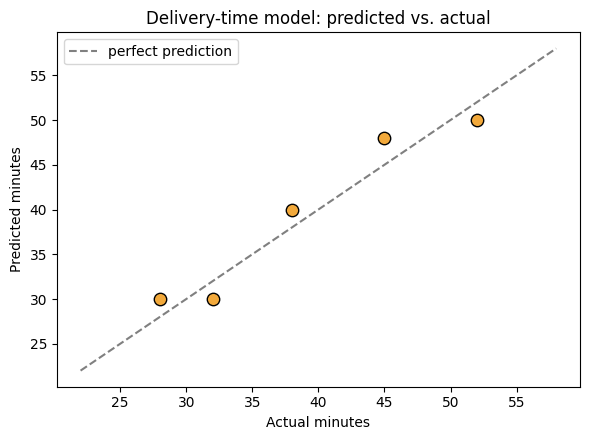

In [3]:
# Regression: 5 deliveries, actual vs predicted minutes
reg_actual = [32, 45, 28, 52, 38]
reg_pred =   [30, 48, 30, 50, 40]

print(regression_scorecard(reg_actual, reg_pred))
# Expect: RMSE ≈ 2.236, R2 ≈ 0.934

fig, ax = plt.subplots()
lims = [22, 58]
ax.plot(lims, lims, "--", color="gray", label="perfect prediction")
ax.scatter(reg_actual, reg_pred, s=80, color="#F2A93B", edgecolor="black", zorder=3)
ax.set_xlabel("Actual minutes"); ax.set_ylabel("Predicted minutes")
ax.set_title("Delivery-time model: predicted vs. actual")
ax.legend()
plt.tight_layout(); plt.show()


{'Accuracy': 0.75, 'Precision': 0.7142857142857143, 'Recall': 0.625, 'F1': 0.6666666666666666}


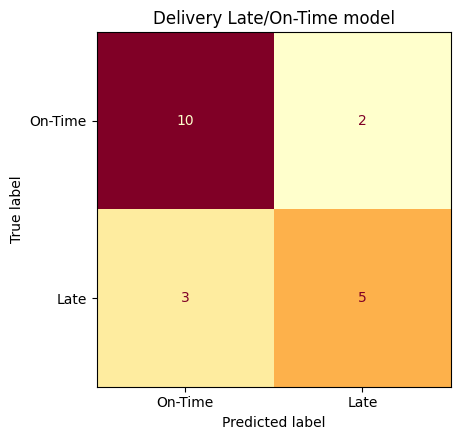

In [4]:
# Classification: 20 deliveries, actual vs predicted Late(1)/On-Time(0)
clf_actual = [1]*5 + [1]*3 + [0]*10 + [0]*2
clf_pred   = [1]*5 + [0]*3 + [0]*10 + [1]*2

print(classification_scorecard(clf_actual, clf_pred))
# Expect: Accuracy=0.75, Precision≈0.714, Recall=0.625, F1≈0.667

ConfusionMatrixDisplay.from_predictions(
    clf_actual, clf_pred, display_labels=["On-Time", "Late"], cmap="YlOrRd", colorbar=False
)
plt.title("Delivery Late/On-Time model")
plt.tight_layout(); plt.show()


## 3. Why the two scorecards can't be merged

Averaging R² and F1 produces a number that hides the classification model's real weakness.


In [5]:
r2 = regression_scorecard(reg_actual, reg_pred)["R2"]
f1 = classification_scorecard(clf_actual, clf_pred)["F1"]

print(f"Naive average of R2 ({r2:.3f}) and F1 ({f1:.3f}): {(r2 + f1) / 2:.3f}")
print("That 0.80 looks solid — but it hides that Recall is only 0.625:")
print("the classifier is missing over a third of the genuinely late deliveries.")


Naive average of R2 (0.934) and F1 (0.667): 0.800
That 0.80 looks solid — but it hides that Recall is only 0.625:
the classifier is missing over a third of the genuinely late deliveries.


## 4. Model selection on real data

Real evaluation work usually means comparing more than one candidate model. Let's fit **two** models per problem type on real, built-in Scikit-learn datasets, score both with our reusable scorecards, visualize the difference, and pick a winner — exactly the workflow this session is named for.


### 4a. Regression: `LinearRegression` vs. `DecisionTreeRegressor`

Dataset: `load_diabetes` — 442 real patients, predicting disease progression from 10 measurements.


In [6]:
diabetes = load_diabetes()
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.3, random_state=42
)

lin_reg = LinearRegression().fit(Xr_train, yr_train)
tree_reg = DecisionTreeRegressor(max_depth=4, random_state=42).fit(Xr_train, yr_train)

lin_pred = lin_reg.predict(Xr_test)
tree_pred = tree_reg.predict(Xr_test)

regression_results = pd.DataFrame({
    "LinearRegression": regression_scorecard(yr_test, lin_pred),
    "DecisionTreeRegressor": regression_scorecard(yr_test, tree_pred),
}).round(3)
regression_results


,LinearRegression,DecisionTreeRegressor
RMSE,53.120,60.410
R2,0.477,0.324


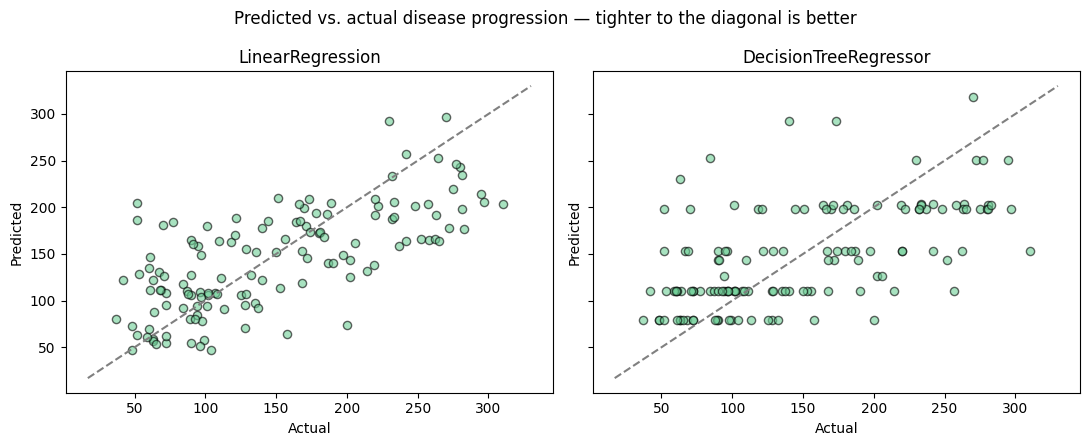

Winner by RMSE: LinearRegression


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
lims = [yr_test.min() - 20, yr_test.max() + 20]

for ax, pred, name in zip(axes, [lin_pred, tree_pred], ["LinearRegression", "DecisionTreeRegressor"]):
    ax.plot(lims, lims, "--", color="gray")
    ax.scatter(yr_test, pred, alpha=0.6, color="#6FCF97", edgecolor="black", s=35)
    ax.set_title(name)
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")

plt.suptitle("Predicted vs. actual disease progression — tighter to the diagonal is better")
plt.tight_layout(); plt.show()

print(f"Winner by RMSE: {'LinearRegression' if regression_results.loc['RMSE'].idxmin() == 'LinearRegression' else 'DecisionTreeRegressor'}")


**In this run**, `LinearRegression` wins on both RMSE and R² — its predictions cluster closer to the diagonal in the scatter above, and a shallow decision tree can only output a handful of discrete prediction values, which shows up as the tree's points forming visible horizontal bands instead of tracking the diagonal.


### 4b. Classification: `LogisticRegression` vs. `DecisionTreeClassifier`

Dataset: `load_breast_cancer` — 569 real diagnostic scans. We treat "malignant" as the positive class, the case most worth catching.


In [8]:
cancer = load_breast_cancer()
y_cancer = (cancer.target == 0).astype(int)  # 1 = malignant (positive class)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    cancer.data, y_cancer, test_size=0.3, random_state=42, stratify=y_cancer
)

scaler = StandardScaler()
Xc_train_scaled, Xc_test_scaled = scaler.fit_transform(Xc_train), scaler.transform(Xc_test)

log_clf = LogisticRegression(max_iter=5000).fit(Xc_train_scaled, yc_train)
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42).fit(Xc_train, yc_train)  # trees don't need scaling

log_pred = log_clf.predict(Xc_test_scaled)
tree_clf_pred = tree_clf.predict(Xc_test)

classification_results = pd.DataFrame({
    "LogisticRegression": classification_scorecard(yc_test, log_pred),
    "DecisionTreeClassifier": classification_scorecard(yc_test, tree_clf_pred),
}).round(3)
classification_results


,LogisticRegression,DecisionTreeClassifier
Accuracy,0.971,0.906
Precision,0.984,0.962
Recall,0.938,0.781
F1,0.960,0.862


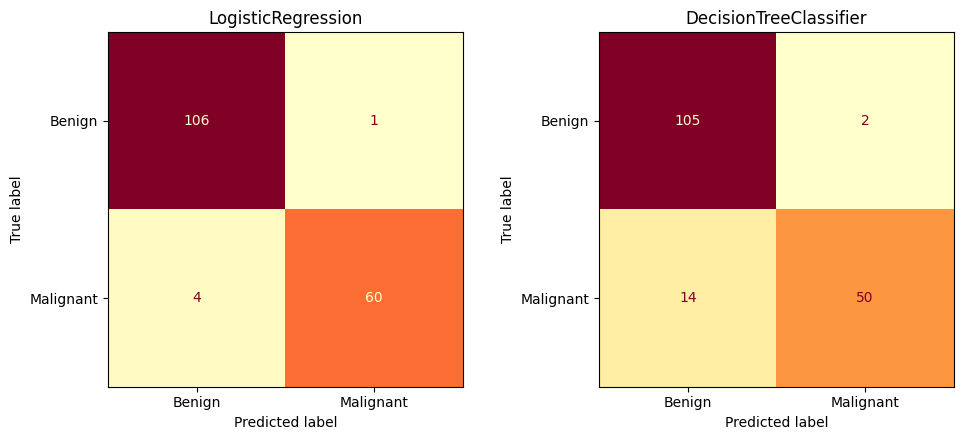

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, pred, name in zip(axes, [log_pred, tree_clf_pred], ["LogisticRegression", "DecisionTreeClassifier"]):
    ConfusionMatrixDisplay.from_predictions(
        yc_test, pred, display_labels=["Benign", "Malignant"], cmap="YlOrRd", colorbar=False, ax=ax
    )
    ax.set_title(name)
plt.tight_layout(); plt.show()


In [10]:
print("Full classification_report for the stronger model (LogisticRegression):\n")
print(classification_report(yc_test, log_pred, target_names=["Benign", "Malignant"]))


Full classification_report for the stronger model (LogisticRegression):

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.98       107
   Malignant       0.98      0.94      0.96        64

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



**In this run**, `LogisticRegression` wins on every metric — most importantly Recall (catching more of the actual malignant cases). The confusion matrices make this visible directly: the tree's matrix has more cases in the "actually malignant, predicted benign" cell — exactly the false negatives that matter most in a screening context.


## 5. Exercises


**Exercise 1.** A second delivery-time model predicts `[44, 50, 35, 58]` against actual `[40, 55, 33, 61]`. Call `regression_scorecard` on it.


In [11]:
# TODO



<details><summary>Solution</summary>

```python
print(regression_scorecard([40, 55, 33, 61], [44, 50, 35, 58]))
# RMSE ≈ 3.674, R2 ≈ 0.893
```
</details>


**Exercise 2.** A teammate says: "Our R² is 0.91 and our Accuracy is 0.88, so on average we're at 0.895." What's wrong with that, based on Section 3?


<details><summary>Solution</summary>

R² and Accuracy measure different kinds of correctness (explained variance vs. label hit-rate) and aren't on a combinable scale. Averaging them, like averaging R² and F1 above, can hide a real weakness in whichever model is worse — report each scorecard separately instead.
</details>


**Exercise 3.** Using `regression_results` from Section 4a, write one line of code that prints just the winning model's name based on R² (higher is better), then run it.


In [12]:
# TODO



<details><summary>Solution</summary>

```python
print(regression_results.loc["R2"].idxmax())
# LinearRegression
```
</details>


## 6. Recap

- Regression outcomes are compared by **distance** (RMSE, R²); classification outcomes are compared by **which bucket** a prediction landed in (Accuracy, Precision, Recall, F1).
- The two families **can't be merged into one number** — averaging across them hides real weaknesses.
- **Model selection** means fitting more than one candidate, scoring each with the same scorecard, and picking a winner using visuals (predicted-vs-actual plots, confusion matrices) alongside the raw numbers — not the numbers alone.
- Scikit-learn's `sklearn.metrics` holds every function used here — including ready-made displays like `ConfusionMatrixDisplay` and `classification_report` — under one import, for both problem types.
